In [25]:
%matplotlib inline 

In [26]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_wavefield_custom_stf_from_mpm" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# # Add code to keep .gitignore updated to ignore salvus files
# gitignore_path = pathlib.Path("..") / ".gitignore"
# with open(gitignore_path, "r+") as f:
#     contents = f.read()
#     if PROJECT_DIR not in contents:
#         f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import salvus.flow.simple_config as sc
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output
import salvus.flow.api

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

In [27]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

[2026-07-15 11:05:00,757] INFO: Loading project from simulation_wavefield_custom_stf_from_mpm.


Keys in the NPZ file: ['times', 'x_centers', 'y_centers', 'M11', 'M22', 'M12', 'dM11', 'dM12', 'dM22']


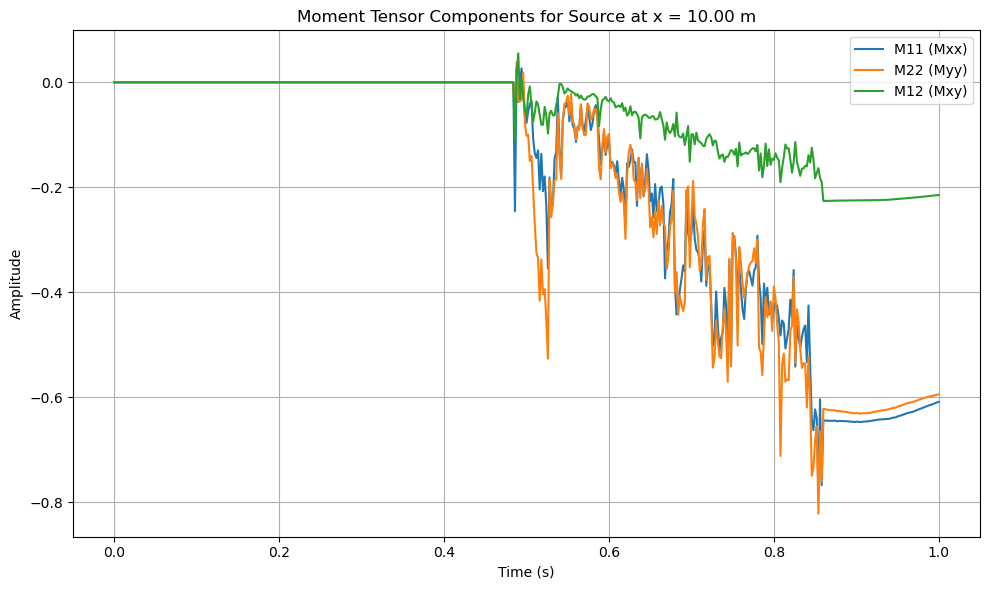

In [28]:
import numpy as np
import matplotlib.pyplot as plt

#Load  .npz archive
data = np.load('test_mpm_mij_B-reference_tau0p3549s.npz')

# Check keys of arrays inside
print("Keys in the NPZ file:", data.files)

# Extract the coordinate and time arrays
times = data['times']
x_centers = data['x_centers']

# Extract Moment Tensor Components and rename them to be the same as slavus 
m11 = np.squeeze(data['M11']) 
m22 = np.squeeze(data['M22']) 
m12 = np.squeeze(data['M12'])


# Plot components of 0th source to check 
source_idx = 1000

if m11.shape[0] == len(times):
    y11 = m11[:, source_idx]
    y22 = m22[:, source_idx]
    y12 = m12[:, source_idx]
else:
    y11 = m11[source_idx, :]
    y22 = m22[source_idx, :]
    y12 = m12[source_idx, :]

plt.figure(figsize=(10, 6))
plt.plot(times, y11, label='M11 (Mxx)', linewidth=1.5)
plt.plot(times, y22, label='M22 (Myy)', linewidth=1.5)
plt.plot(times, y12, label='M12 (Mxy)', linewidth=1.5)

plt.title(f'Moment Tensor Components for Source at x = {x_centers[source_idx]:.2f} m')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
display(plt.gcf())
plt.close()

In [29]:
import numpy as np
import salvus.namespace as sn

# Load dta to analyze freuebncy content
# We load the data here first to analyze the frequency content for the mesh
npz_data = np.load('test_mpm_mij_B-reference_tau0p3549s.npz')
times = npz_data['times']
dt = times[1] - times[0]

m11_raw = np.squeeze(npz_data['M11'])
m11 = m11_raw if m11_raw.shape[0] == len(times) else m11_raw.T


wavelet_base = np.gradient(m11[:, 1000], dt)
n_fft = len(wavelet_base)
fft_vals = np.fft.rfft(wavelet_base)
frequencies = np.fft.rfftfreq(n_fft, d=dt)
amplitude_spectrum = np.abs(fft_vals)

cumulative_amplitude = np.cumsum(amplitude_spectrum)
total_amplitude = cumulative_amplitude[-1]

percentile_95_idx = np.where(cumulative_amplitude >= 0.95 * total_amplitude)[0][0]
max_frequency = float(frequencies[percentile_95_idx])

# Calculate abc parameters
slowest_velocities = np.array([67.9366, 67.9366, 300.0])  # Updated to match vs

# Calculate wavelength using the actual source max_frequency instead of a hardcoded 20 Hz
min_wavelength = slowest_velocities[0] / max_frequency
abc_thickness = min_wavelength * 3.5

print(f"95th Percentile Source Frequency: {max_frequency:.1f} Hz")
print(f"Calculated max wavelength for meshing: {min_wavelength:.3f} m")
print(f"Calculated ABC thickness (3.5 * lambda): {abc_thickness:.3f} m")

# Domain 
x_min, x_max = 0.0, 400.0
slab_top, slab_bottom = 3.0, 2.25
wl_top, wl_bottom = 2.25, 1.5
air_top, air_bottom = 1.5, 0.0

layers_x = [np.array([x_min, x_max])] * 4
layers_y = [
    np.array([slab_top, slab_top]),
    np.array([slab_bottom, slab_bottom]),
    np.array([wl_bottom, wl_bottom]),
    np.array([air_bottom, air_bottom]),
]

vp = np.array([109.4, 109.4, 330.0]) 
vs = np.array([67.9366, 67.9366, 0.0])   
rho = np.array([250.0, 250.0, 1.225])

splines = sn.toolbox.get_interpolating_splines(layers_x, layers_y, kind=["linear"]*4)

# Mesh
mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2.5,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    absorbing_boundaries=(["x0", "x1", "y0"], abc_thickness), # Dynamically apply thinner ABCs
)
mesh = np.sum(mesh)

nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    idx = np.where(mesh.elemental_fields["region"] == _i)
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

mesh_3layer = sn.toolbox.detect_fluid(mesh)
print("\nThree-layer mesh built successfully!")
print(f"Sources at y=2.625m are safely {(2.625 - abc_thickness):.2f}m above the bottom ABC.")

95th Percentile Source Frequency: 214.6 Hz
Calculated max wavelength for meshing: 0.317 m
Calculated ABC thickness (3.5 * lambda): 1.108 m

Three-layer mesh built successfully!
Sources at y=2.625m are safely 1.52m above the bottom ABC.


In [ ]:
import numpy as np
import salvus.flow.simple_config as sc

# Load data
print("Loading raw MPM moment tensor data...")
npz_data = np.load('test_mpm_mij_B-reference_tau0p3549s.npz')

times = npz_data['times']
x_coords = npz_data['x_centers']
y_coords = npz_data['y_centers']

# Exact native sampling rate
dt = times[1] - times[0]
sampling_rate = 1.0 / dt

m11_raw = np.squeeze(npz_data['M11'])
m22_raw = np.squeeze(npz_data['M22'])
m12_raw = np.squeeze(npz_data['M12'])

if m11_raw.shape[0] == len(times):
    m11, m22, m12 = m11_raw, m22_raw, m12_raw
else:
    m11, m22, m12 = m11_raw.T, m22_raw.T, m12_raw.T

# Filter data in abc
x_left_abc = x_min + abc_thickness
x_right_abc = x_max - abc_thickness

# Collect indices of sources that fall outside the ABCs (the active zone)
active_indices = []
for i in range(len(x_coords)):
    x = float(x_coords[i])
    if x_left_abc < x < x_right_abc:
        active_indices.append(i)

num_active = len(active_indices)
print(f"Total raw sources: {len(x_coords)}")
print(f"Active sources (outside ABCs): {num_active}")
print(f"Skipped sources inside ABCs: {len(x_coords) - num_active}")

# Calculate index based taper 
active_x = x_coords[active_indices]
dx_between_sources = np.median(np.diff(active_x))

# Calculate delay between soutces based on the first time the signal exceeds a threshold (1% of max amplitude)
initiation_times = []
for idx in active_indices:
    signal = np.abs(m11[:, idx])
    threshold = 0.01 * np.max(signal)
    triggered_indices = np.where(signal > threshold)[0]
    if len(triggered_indices) > 0:
        initiation_times.append(times[triggered_indices[0]])
    else:
        initiation_times.append(0.0)

delay_between_sources = np.median(np.diff(initiation_times))
if delay_between_sources <= 0:
    # Fallback default if initiation times cannot be computed reliably
    delay_between_sources = 0.0018  # s

# Set half-width of the source wavelet
half_width = 0.03549  

# Calculate how many soucres are tapered
N_taper = int(half_width / delay_between_sources) + 1
# Ensure N_taper doesn't exceed half of our active sources
N_taper = min(N_taper, num_active // 2)

print(f"Calculated source spacing: {dx_between_sources:.4f} m")
print(f"Calculated delay between sources: {delay_between_sources:.6f} s")
print(f"Tapering the first and last {N_taper} active sources")

# Build the Hanning window taper array for the active sources
taper = np.ones(num_active)
taper[:N_taper] = np.hanning(2 * N_taper)[:N_taper]     # Rising half
taper[-N_taper:] = np.hanning(2 * N_taper)[N_taper:]    # Falling half

# Build Salvus source s
srcs = []

for active_idx, original_idx in enumerate(active_indices):
    x = float(x_coords[original_idx])
    
    # Get the specific taper weight for this active index
    weight = taper[active_idx]
    
    # Apply the Hanning weight directly to the STFs
    mxx = m11[:, original_idx] * weight
    myy = m22[:, original_idx] * weight
    mxy = m12[:, original_idx] * weight
    
    stf_array = np.column_stack((mxx, myy, mxy))
    
    stf = sc.stf.Custom.from_array(
        array=stf_array,
        sampling_rate_in_hertz=sampling_rate,
        start_time_in_seconds=times[0], 
    )
    
    src = sc.source.cartesian.MomentTensorPoint2D(
        x=x,
        y=2.625,
        mxx=1.0,
        myy=1.0,
        mxy=1.0,
        source_time_function=stf,
    )
    srcs.append(src)

print(f"Successfully generated {len(srcs)} sources with an index-based taper.")

Loading raw MPM moment tensor data...
Total raw sources: 4000
Active sources (outside ABCs): 3889
Skipped sources inside ABCs: 111
Calculated source spacing: 0.0100 m
Calculated delay between sources: 0.001800 s
Tapering the first and last 20 active sources
Successfully generated 3889 sources with an index-based taper.


In [31]:
import h5py


h5_path = srcs[0].source_time_function.filename
dataset_name = srcs[0].source_time_function.dataset_name
wavelet_type = srcs[0].source_time_function.wavelet

print(f"Wavelet Type: {wavelet_type}")
print(f"HDF5 File Location: {h5_path}")
print(f"Dataset Name inside HDF5: {dataset_name}\n")

# Open  file to look at the raw custom wavelet data structure
with h5py.File(h5_path, 'r') as f:
    dset = f[dataset_name]
    
    print("--- Dataset Details ---")
    print("Array Shape (n_components, n_samples):", dset.shape)
    print("Data Type:", dset.dtype)
    
    print("\n--- Meta-Data Attributes Attached by Salvus ---")
    for key, val in dset.attrs.items():
        print(f"  {key}: {val}")
        
    # first 10 numerical values of the actual wavelet array
    print("\nFirst 10 amplitude values of the custom array:")
    print(dset[:10])

    

Wavelet Type: custom
HDF5 File Location: /tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__2607151105312598437de081__2210536/custom_stf.h5
Dataset Name inside HDF5: /stf

--- Dataset Details ---
Array Shape (n_components, n_samples): (501, 3)
Data Type: float64

--- Meta-Data Attributes Attached by Salvus ---
  sampling_rate_in_hertz: 500.0
  start_time_in_seconds: 0.0

First 10 amplitude values of the custom array:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


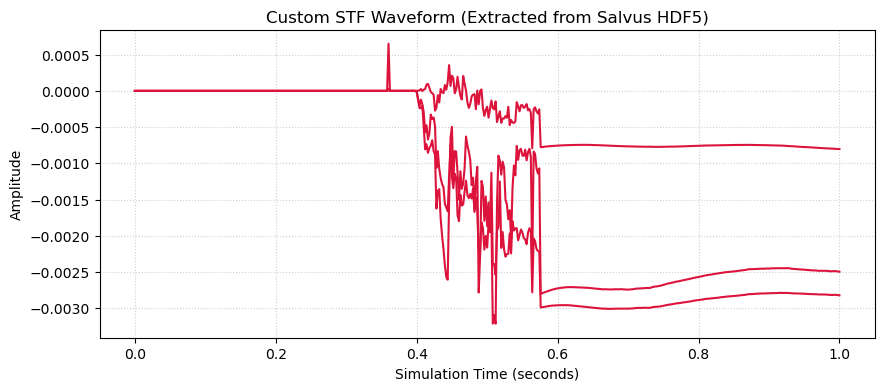

In [32]:


# Path and dataset pointer form object for first source 
h5_path = srcs[1].source_time_function.filename
dataset_name = srcs[1].source_time_function.dataset_name

# Extract the array and metadata from the HDF5 file
with h5py.File(h5_path, 'r') as f:
    dset = f[dataset_name]
    stf_array = np.squeeze(dset[:]) # Squeeze removes empty dimensions 
    
    # Extract attributes
    sampling_rate = dset.attrs.get('sampling_rate_in_hertz', 10000.0)
    start_time = dset.attrs.get('start_time_in_seconds', 0.0)

# Time axis of soutce 
dt = 1.0 / sampling_rate
time_axis = start_time + (np.arange(len(stf_array)) * dt)


plt.figure(figsize=(10, 4))
plt.plot(time_axis, stf_array, color='crimson', lw=1.5)
plt.xlabel('Simulation Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Custom STF Waveform (Extracted from Salvus HDF5)')
plt.grid(True, linestyle=':', alpha=0.6)
display(plt.gcf())
plt.close()

In [33]:
# Initialize simulation object, pass multiple sources
sim = sc.simulation.Waveform(mesh=mesh_3layer, sources=srcs)

# physics parameters 
sim.physics.wave_equation.end_time_in_seconds = 6.545
sim.physics.wave_equation.start_time_in_seconds = -0.2

abc_sides = sc.boundary.Absorbing(
    width_in_meters=float(abc_thickness), 
    side_sets=["x0", "x1"],
    taper_amplitude=max_frequency * 2.0,
    side_sets_are_axis_aligned=True
)

abc_bottom = sc.boundary.Absorbing(
    width_in_meters=1.0, 
    side_sets=["y0"],
    taper_amplitude=max_frequency * 2.0,
    side_sets_are_axis_aligned=True
)

sim.physics.wave_equation.boundaries = [abc_sides, abc_bottom]

sim.output.volume_data.format = "hdf5"
sim.output.volume_data.fields = ["displacement", "velocity"]
sim.output.volume_data.filename = "volume_data_output.h5"
sim.output.volume_data.sampling_interval_in_time_steps = 50


moving_source_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")

print(f"Launching simulation. Outputs will be copied to: {moving_source_output_folder}")


Launching simulation. Outputs will be copied to: simulation_wavefield_custom_stf_from_mpm/custom_job_moving_source_all_sources


In [ ]:


# Launchg
salvus.flow.api.run(
    input_file=sim,
    site_name=SALVUS_FLOW_SITE_NAME,
    ranks=RANKS_PER_JOB,
    output_folder=moving_source_output_folder,
    overwrite=True,
    get_all=True, 
)

print("Run finished successfully!")

SalvusJob `job_2607151105159931_051b2cf17c` running on `salome_remote_2` with 4 rank(s).
Site information:
  * Salvus version: 2025.1.2
  * Floating point size: 32


Solving forward problem/Computing forward wavefield:   0%|          | 0/126926 [00:00<?, ?it/s]

In [ ]:
vol_file = pathlib.Path(moving_source_output_folder) / "volume_data_output.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

vel_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "velocity",
    "volume",
)

vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 400, 1601), np.linspace(0, 3, 101)],
)

print(f"Loaded velocity from {vol_file}")
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/161701 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

[2026-07-15 10:11:28,079] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 80050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded velocity from simulation_wavefield_custom_stf_from_mpm/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 2540, c: 2, x: 1601, y: 101)> Size: 3GB
array([[[[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

     

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.2 -> 6.546275388809227
vx shape: (2540, 1601)
vy shape: (2540, 1601)


/tmp/ipykernel_2210536/1095561471.py:56: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_2210536/1095561471.py:78: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


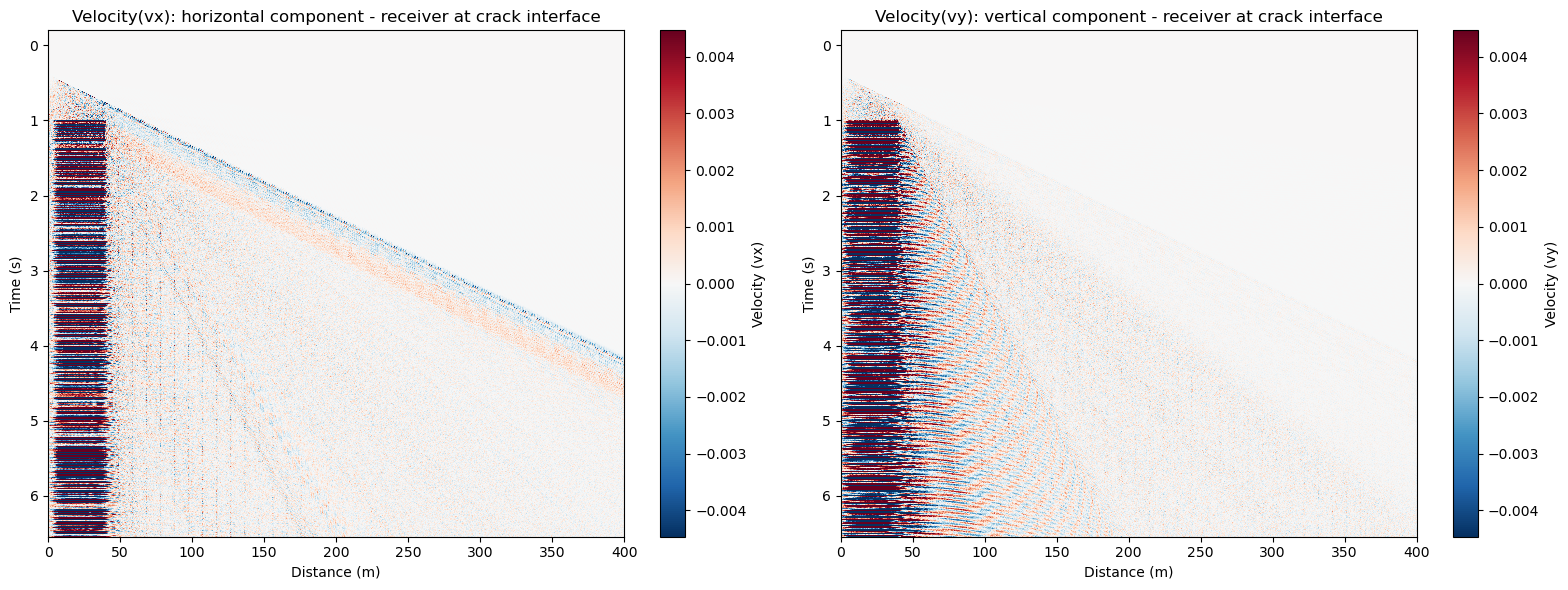

In [ ]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 # 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx): horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy): vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

In [ ]:
# loading displacement
# Extract displacement wavefield output from the single combined run.
czm_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")
vol_file = pathlib.Path(czm_output_folder) / "volume_data_output.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

dis_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "displacement",
    "volume",
)

dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    dis_wo,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

print(f"Loaded displacement from {vol_file}")
print(f"Shape: {dis_2d_layered.dims}")
print(dis_2d_layered)

# Take the spatial derivative of the layered displacement field along x.
x_dim = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in dis_2d_layered.dims or dim in dis_2d_layered.coords), None)

if x_dim is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={dis_2d_layered.dims}, coords={list(dis_2d_layered.coords)}"
    )

dis_2d_layered_dx = dis_2d_layered.differentiate(x_dim)

print(f"Computed spatial derivative d/d{x_dim} for dis_2d_layered")
print(dis_2d_layered_dx)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/40501 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

[2026-07-15 10:16:19,062] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 20050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded displacement from simulation_wavefield_custom_stf_from_mpm/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 2540, c: 2, x: 401, y: 101)> Size: 823MB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           nan,           

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.2 -> 6.546275388809227
vx shape: (2540, 401)
vy shape: (2540, 401)


/tmp/ipykernel_2210536/2342594202.py:60: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_2210536/2342594202.py:82: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


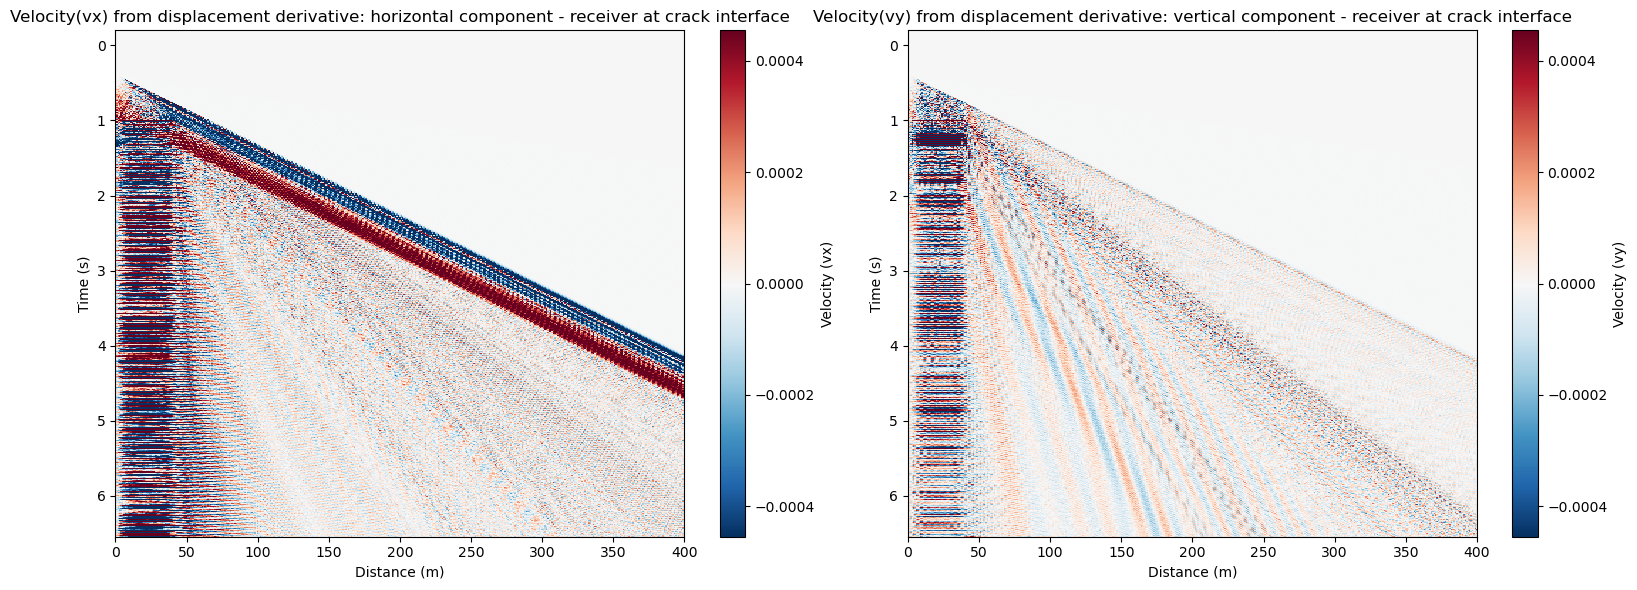

In [ ]:
# instead of velocity: temporal derivative of displacement to get velocity
dis_2d_layered_dt = dis_2d_layered.differentiate(t_name)

# plotting displacement temporal derivative (velocity)
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 # 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(dis_2d_layered_dt.coords)
dims_set = set(dis_2d_layered_dt.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={dis_2d_layered_dt.dims}, coords={list(dis_2d_layered_dt.coords)}")

# Select both components at y receiver line
sg_vx = dis_2d_layered_dt.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = dis_2d_layered_dt.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx) from displacement derivative: horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy) from displacement derivative: vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

In [ ]:
# animation 
# =============================================================================
# UNIFIED WAVEFIELD ANIMATION ENGINE (Vy & Vx)
# =============================================================================
import pathlib
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import display
from salvus.toolbox.helpers import wavefield_output

# Always reload the latest simulation output from disk
base_dir = globals().get('PROJECT_DIR', "simulation_wavefield_custom_stf_weighted_simpler_mesh_dense")
project_path = pathlib.Path(base_dir) / "custom_job_moving_source_all_sources"

output_candidates = sorted(project_path.glob("**/volume_data_output.h5"), key=lambda path: path.stat().st_mtime, reverse=True)
if not output_candidates:
    raise RuntimeError(f"Missing output file under {project_path}: volume_data_output.h5")
vol_file = output_candidates[0]
print(f"Using latest wavefield file: {vol_file}")

vel_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "velocity", "volume")
vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

# Resolve coordinate and dimension naming conventions robustly
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)
x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if None in [x_name, y_name, t_name, c_name]:
    raise ValueError(f"Could not resolve dimensions from dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

receiver_y = 2.625

# =============================================================================
# PART 1: VERTICAL VELOCITY COMPONENT (vy)
# =============================================================================
print("\n--- Processing Animation 1/2: Velocity (vy) ---")
vy_event = vel_2d_layered.isel({c_name: 1})  # Component 1 = vy
if e_name is not None and e_name in vy_event.dims:
    vy_event = vy_event.mean(dim=e_name)
vy_event = vy_event.transpose(t_name, y_name, x_name)

x_vals_y = vy_event[x_name].values
y_vals_y = vy_event[y_name].values
t_vals_y = vy_event[t_name].values
frames_3d_y = np.asarray(vy_event.values, dtype=np.float64)
frames_3d_y = np.nan_to_num(frames_3d_y, nan=0.0, posinf=0.0, neginf=0.0)

t_start_idx = np.searchsorted(t_vals_y, 0.0)
N = 8
raw_idx_y = np.arange(t_start_idx, frames_3d_y.shape[0], N)
max_frames = 350
t_idx_y = raw_idx_y[:max_frames]

# Robust symmetric color scaling
sample_abs_y = np.abs(frames_3d_y[t_idx_y]).ravel()
sample_abs_y = sample_abs_y[np.isfinite(sample_abs_y) & (sample_abs_y > 1e-14)]
vmax_y = max(float(np.percentile(sample_abs_y, 99.0)), 1e-8) if sample_abs_y.size > 0 else 1e-8
norm_y = matplotlib.colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax_y, vmax=vmax_y)

fig_y, ax_y = plt.subplots(figsize=(12, 4), constrained_layout=True)
im_y = ax_y.imshow(
    frames_3d_y[t_idx_y[0]],
    extent=[x_vals_y.min(), x_vals_y.max(), y_vals_y.max(), y_vals_y.min()],
    aspect="auto",
    cmap="RdBu_r",
    norm=norm_y,
    origin="upper",
    interpolation="nearest",
)

ax_y.axhline(1.5, color="black", lw=1.2, linestyle="--", label=f"snow-air  (y=1.5 m)")
ax_y.set_xlabel("x (m)")
ax_y.set_ylabel("Depth (m)")
ax_y.set_xlim(x_vals_y.min(), x_vals_y.max())
ax_y.set_ylim(y_vals_y.max(), y_vals_y.min())
ax_y.legend(loc="upper right", fontsize=8)
plt.colorbar(im_y, ax=ax_y, label="Velocity (vy)", shrink=0.8)
title_y = ax_y.set_title(f"Wavefield Velocity(vy) - t = {t_vals_y[t_idx_y[0]]:.4f} s at snow bottom (y=2.25 m)")

def update_y(frame_idx):
    ti = t_idx_y[frame_idx]
    im_y.set_data(frames_3d_y[ti])
    title_y.set_text(f"Wavefield Velocity(vy) - t = {t_vals_y[ti]:.4f} s")
    return im_y, title_y

ani_y = animation.FuncAnimation(fig_y, update_y, frames=len(t_idx_y), interval=90, blit=False)
output_name_y = "custom_sub_wavefield_2d_moving_vy_crack.gif"
print(f"Saving {output_name_y}...")
ani_y.save(output_name_y, writer=animation.PillowWriter(fps=15), dpi=80)
plt.close(fig_y)
print(f"Done! Saved as {output_name_y}")


# =============================================================================
# PART 2: HORIZONTAL VELOCITY COMPONENT (vx)
# =============================================================================
print("\n--- Processing Animation 2/2: Velocity (vx) ---")
vx_event = vel_2d_layered.isel({c_name: 0})  # Component 0 = vx
if e_name is not None and e_name in vx_event.dims:
    vx_event = vx_event.mean(dim=e_name)
vx_event = vx_event.transpose(t_name, y_name, x_name)

# Arrays are extracted purely from the independent vx_event structure
x_vals_x = vx_event[x_name].values
y_vals_x = vx_event[y_name].values
t_vals_x = vx_event[t_name].values
frames_3d_x = np.asarray(vx_event.values, dtype=np.float64)
frames_3d_x = np.nan_to_num(frames_3d_x, nan=0.0, posinf=0.0, neginf=0.0)

raw_idx_x = np.arange(np.searchsorted(t_vals_x, 0.0), frames_3d_x.shape[0], N)
t_idx_x = raw_idx_x[:max_frames]

sample_abs_x = np.abs(frames_3d_x[t_idx_x]).ravel()
sample_abs_x = sample_abs_x[np.isfinite(sample_abs_x) & (sample_abs_x > 1e-14)]
vmax_x = max(float(np.percentile(sample_abs_x, 99.0)), 1e-8) if sample_abs_x.size > 0 else 1e-8
norm_x = matplotlib.colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax_x, vmax=vmax_x)

fig_x, ax_x = plt.subplots(figsize=(12, 4), constrained_layout=True)
im_x = ax_x.imshow(
    frames_3d_x[t_idx_x[0]],
    extent=[x_vals_x.min(), x_vals_x.max(), y_vals_x.max(), y_vals_x.min()],
    aspect="auto",
    cmap="RdBu_r",
    norm=norm_x,
    origin="upper",
    interpolation="nearest",
)

ax_x.axhline(1.5, color="black", lw=1.2, linestyle="--", label=f"snow-air  (y=1.5 m)")
ax_x.set_xlabel("x (m)")
ax_x.set_ylabel("Depth (m)")
ax_x.set_xlim(x_vals_x.min(), x_vals_x.max())
ax_x.set_ylim(y_vals_x.max(), y_vals_x.min())
ax_x.legend(loc="upper right", fontsize=8)
plt.colorbar(im_x, ax=ax_x, label="Velocity (vx)", shrink=0.8)
title_x = ax_x.set_title(f"Wavefield Velocity(vx) - t = {t_vals_x[t_idx_x[0]]:.4f} s at crack location (y = 2.625m)")

def update_x(frame_idx):
    ti = t_idx_x[frame_idx]
    im_x.set_data(frames_3d_x[ti])
    title_x.set_text(f"Wavefield Velocity(vx) - t = {t_vals_x[ti]:.4f} s")
    return im_x, title_x

ani_x = animation.FuncAnimation(fig_x, update_x, frames=len(t_idx_x), interval=90, blit=False)

if animation.writers.is_available("ffmpeg"):
    writer_x = animation.FFMpegWriter(
        fps=15,
        codec="libx264",
        extra_args=["-pix_fmt", "yuv420p", "-crf", "28"],
    )
    output_name_x = "custom_weighted_sub_wavefield_2d_moving_vx_crack.mp4"
else:
    writer_x = animation.PillowWriter(fps=10)
    output_name_x = "custom_weighted_sub_wavefield_2d_moving_vx_crack.gif"

print(f"Saving {output_name_x}...")
ani_x.save(output_name_x, writer=writer_x, dpi=80)
plt.close(fig_x)
print(f"Done! Saved as {output_name_x}")

Using latest wavefield file: simulation_wavefield_custom_stf_from_mpm/custom_job_moving_source_all_sources/volume_data_output.h5


KeyboardInterrupt: 

In [ ]:
# Frequency domain analysis: f-k analysis with symmetric V-line overlays
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
from IPython.display import display

# Verify rupture velocity
print(f"Rupture speed taken is {target_vprop} m/s")

# Surface shot gather selection
y_recv = 2.25   # Snow coordinate target position
# FIX: Changed .isel to .sel so method="nearest" handles physical coordinate mapping correctly
sg = vel_2d_layered.sel(
    {y_name: y_recv},
    method="nearest"
).isel({c_name: 0}) # vx component

t_vals = sg[t_name].values
x_vals = sg[x_name].values
data = sg.values 

# Force data strictly into (nt, nx) shape
if data.shape[0] == len(x_vals):
    data = data.T

nt, nx = data.shape
dt = float(np.nanmedian(np.diff(t_vals)))
dx = float(np.nanmedian(np.diff(x_vals)))

# 2D FFT - f-k spectrum with Hanning Windows
taper_t = np.hanning(nt)
taper_x = np.hanning(nx)
data_tapered = data * taper_t[:, None] * taper_x[None, :]

fk = np.fft.fftshift(np.fft.fft2(data_tapered))
freqs = np.fft.fftshift(np.fft.fftfreq(nt, dt))
wns = np.fft.fftshift(np.fft.fftfreq(nx, dx)) # wavenumber (cycles/m)

# Slice positive frequencies exclusively
f_pos_mask = freqs >= 0
fk_pos = fk[f_pos_mask, :]
# FIX: Properly slice frequency coordinate axis to match pk dimensions
f_plot = freqs[f_pos_mask]

# Define velocity regimes to track
velocities = {
    "vs_slab = 150 m/s": 150.0,
    "rupture speed": target_vprop,
    "vp_slab = 300 m/s": 300.0,
}
# Match colors array exactly to our 3 dictionary objects
colors = ["black", "blue", "green"]

fig, ax = plt.subplots(figsize=(12, 7))

# Build explicit 2D coordinate meshgrid for flawless pcolormesh mapping
WNS, FREQS = np.meshgrid(wns, f_plot)

# Compute power log spectrum
pk = np.log10(np.abs(fk_pos) + 1e-10)
vmax_pk = np.percentile(pk, 99)
vmin_pk = vmax_pk - 4 # 4 decades of dynamic range

mesh = ax.pcolormesh(
    WNS, FREQS, pk,
    shading="nearest", cmap="RdPu",
    vmin=vmin_pk, vmax=vmax_pk,
)

# Overlay symmetric velocity slopes on both sides of the center (k=0) vertex
k_max = wns.max()
for (label, v), col in zip(velocities.items(), colors):
    # Prograde Slope (Right side of V: k = +f/v)
    k_right = f_plot / v
    mask_right = np.abs(k_right) <= k_max
    ax.plot(k_right[mask_right], f_plot[mask_right], color=col, lw=1.8,
            linestyle="--", label=label)
    
    # Retrograde Slope (Left side of V: k = -f/v)
    # Uses same positive f_plot frequency domain to create full opposing slopes
    k_left = -f_plot / v
    mask_left = np.abs(k_left) <= k_max
    ax.plot(k_left[mask_left], f_plot[mask_left], color=col, lw=1.8,
            linestyle="--") # Omit label here so it doesn't duplicate in legend

ax.set_xlim(-k_max * 0.4, k_max * 0.4)
ax.set_ylim(0, min(3 * f0, freqs.max()))
ax.set_xlabel("Wavenumber k (cycles/m)")
ax.set_ylabel("Frequency f (Hz)")
ax.set_title("Symmetric f-k Spectrum of Surface vx — Rupture Velocity Identifications")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.15, color="white", linestyle=":")

# Plot matching interactive colorbar mapping
cbar = fig.colorbar(mesh, ax=ax, shrink=0.9)
cbar.set_label("Relative Power Log10(Mag)", labelpad=10)

plt.tight_layout()
display(fig)
plt.close(fig)

NameError: name 'target_vprop' is not defined